In [2]:
import matplotlib.pyplot as plt
import numpy as np
import math

In [4]:
import control as ct
from control.matlab import *

In [4]:
Plant = ct.tf(1, [10, 1]);

In [29]:
kp = 10; Ti = 10;

In [30]:
Cont = ct.tf([kp * Ti, kp], [Ti, 0])

In [31]:
loop = ct.series (Plant, Cont)

In [16]:
ct.bandwidth(Plant * Cont)

nan

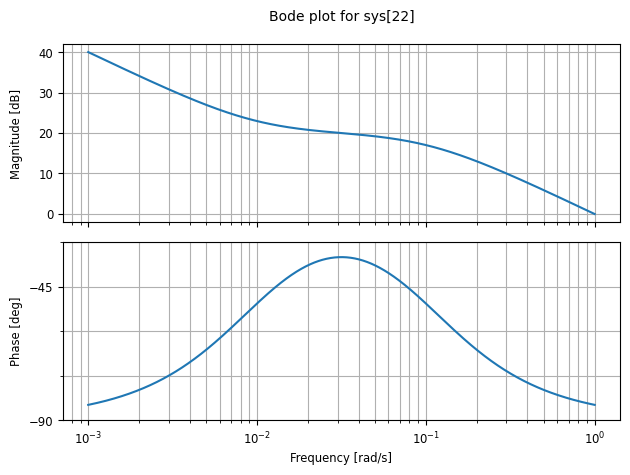

In [32]:
ct.bode(loop)

In [17]:
G = ct.tf([1], [1, 1])

In [ ]:
ct.bandwidth(G)

In [ ]:
ct.bode(sys_clsd)

In [39]:
ct.bandwidth(sys_clsd)

0.8974329450154557

In [34]:
sys_clsd = ct.feedback(loop, 1, sign=-1)

In [35]:
ct.step_info(sys_clsd)

{'RiseTime': 3.4541195416965254,
 'SettlingTime': nan,
 'SettlingMin': 0.9003328291532688,
 'SettlingMax': 1.0,
 'Overshoot': 0,
 'Undershoot': 0,
 'Peak': 0.9198452666369723,
 'PeakTime': 6.332552493110295,
 'SteadyStateValue': 1.0}

In [40]:
rinfo = ct.step_info(sys_clsd)

In [43]:
rinfo['RiseTime']

3.4541195416965254

In [24]:
Plant = ct.tf(1, [10, 1]); Ti = 3;
#list_k = np.arange(2, 50, 0.5);
list_Ti = np.arange(1, 50, 0.5);
list_k = 5*np.ones((len(list_Ti)));
list_Td = np.arange(0.1, 5, 0.05);
list_step  = range(0, len(list_k));
list_bw = np.zeros(len(list_k)); list_rt = np.zeros(len(list_k)); list_bwrt = np.zeros(len(list_k));
for i in list_step:
    kp = list_k[i]; Ti = list_Ti[i]; Td = list_Td[i];
    Cont = ct.tf([kp * Ti, kp], [Ti, 0]) + ct.tf([kp*Td, 1], 1);
    loop = ct.series (Plant, Cont);
    sys_clsd = ct.feedback(loop, 1, sign=-1)
    rinfo = ct.step_info(sys_clsd)
    list_rt[i] = rinfo['RiseTime'];
    list_bw[i] = ct.bandwidth(sys_clsd);
    list_bwrt[i] = list_rt[i]*list_bw[i];
    print("i = ", i, "list_rt[i] = ", list_rt[i], "list_bw[i] = ", list_bw[i], "rt*bw = ", list_rt[i]*list_bw[i])

i =  0 list_rt[i] =  1.6746073403593063 list_bw[i] =  1.120059273365885 rt*bw =  1.8756594808160219
i =  1 list_rt[i] =  1.9287888116638434 list_bw[i] =  0.923022599312197 rt*bw =  1.7803156624662444
i =  2 list_rt[i] =  2.1929381838038533 list_bw[i] =  0.8065498235198049 rt*bw =  1.7687139051368392
i =  3 list_rt[i] =  2.691333225577456 list_bw[i] =  0.7277052580612664 rt*bw =  1.9584973394477032
i =  4 list_rt[i] =  2.9804023498061456 list_bw[i] =  0.6699649432361873 rt*bw =  1.9967650911088735
i =  5 list_rt[i] =  3.045193705236714 list_bw[i] =  0.6254434785111289 rt*bw =  1.9045965437434438
i =  6 list_rt[i] =  3.349214680718612 list_bw[i] =  0.5898424072319122 rt*bw =  1.9755088496115263
i =  7 list_rt[i] =  3.4189899865669173 list_bw[i] =  0.5605944650083333 rt*bw =  1.9166668623883298
i =  8 list_rt[i] =  3.7379628133020217 list_bw[i] =  0.5360602452723258 rt*bw =  2.0037732625175146
i =  9 list_rt[i] =  3.971355216847118 list_bw[i] =  0.5151377994332427 rt*bw =  2.0457951871743

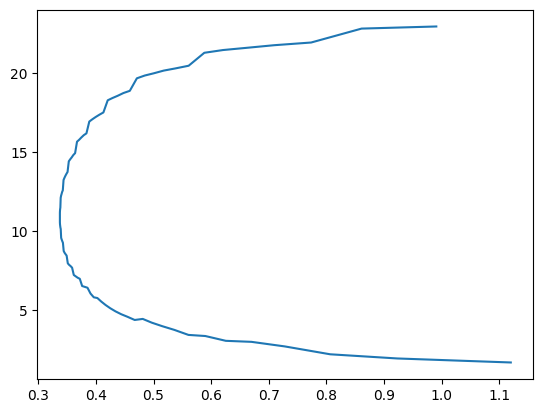

In [25]:
plt.plot(list_bw, list_rt)

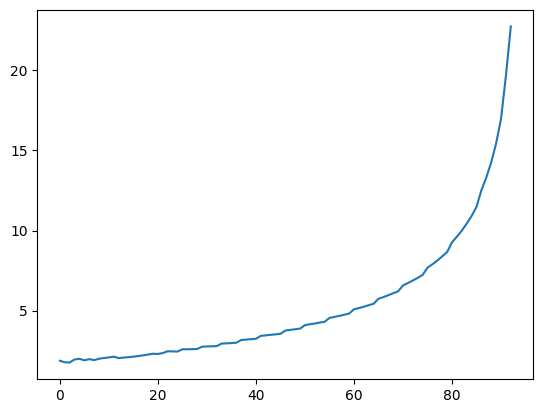

In [26]:
plt.plot(list_bwrt)

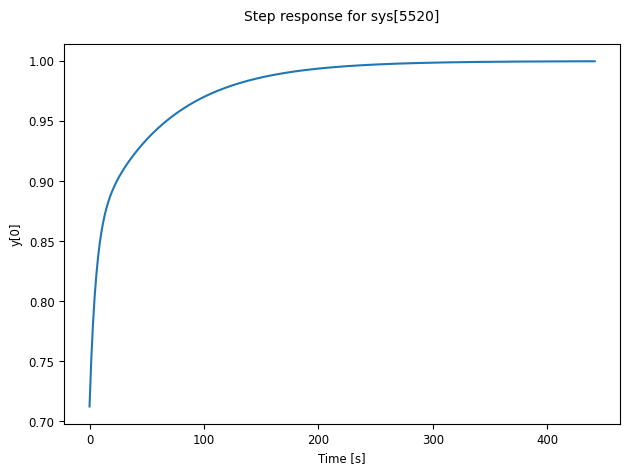

In [27]:
ct.step_response(sys_clsd).plot()

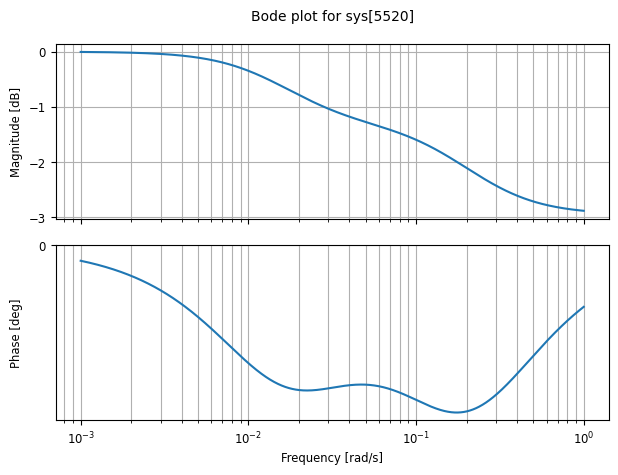

In [31]:
ct.bode(sys_clsd)